# Sanity checks: filtered U.S. panel vs. Fama-French market

Compares the value-weighted (VW) and equally weighted (EW) portfolios of the filtered Datastream panel
with the Fama-French market (Mkt-RF + RF), monthly and daily, and runs a set of universe diagnostics.

**Expectations for the VW portfolio (monthly):** correlation and R² close to one, beta close to one,
alpha statistically indistinguishable from zero, small tracking error. The pass/check flags use the
heuristic thresholds in `datastream.evaluation.THRESHOLDS`.

All functions live in `src/datastream/evaluation.py`; this notebook only configures and displays.
Outputs (tables and figures) are written to `OUTPUT_DIR`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datastream import evaluation as ev
from datastream.ff_data import get_ff_factors, prefetch_ff_cache

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 160)

# ── configuration ───────────────────────────────────────────────────────────────────────────────────
DATA_PATH = Path("D:\\Datastream\\PriceData\\US\\processed")
PENNY_PERCENTILE = 0.25
PANEL_FILE = DATA_PATH / f"US_data_panel_filtered_{PENNY_PERCENTILE}.feather"
DELISTING_RETURN = -0.35          # must match the value used in scripts/02_filter.py
OUTPUT_DIR = DATA_PATH / f"sanity_checks_{PENNY_PERCENTILE}"
ROLLING_MONTHS = 36
ROLLING_DAYS = 252
SUBPERIODS = [                    # (label, start, end) - adjust to your sample
    ("1993-1999", "1993-01", "1999-12"),
    ("2000-2009", "2000-01", "2009-12"),
    ("2010-2019", "2010-01", "2019-12"),
    ("2020-",     "2020-01", "2099-12"),
]

# colors: first two slots of the default categorical palette (dataviz skill); FF is always slot 1
C_FF, C_DS = "#2a78d6", "#eb6834"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load data

In [2]:
df = pd.read_feather(PANEL_FILE)
df["Date"] = pd.to_datetime(df["Date"])
print(f"{len(df):,} stock-days, {df['Stock'].nunique():,} stocks, {df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}")

prefetch_ff_cache(silent=True)     # refreshes stale cache entries without prompting
ff_m = get_ff_factors(3, "monthly")
ff_d = get_ff_factors(3, "daily")
print(f"FF monthly up to {ff_m.index.max()}, FF daily up to {ff_d.index.max():%Y-%m-%d}")

26,328,703 stock-days, 12,339 stocks, 1993-10-04 to 2025-12-31
FF factor cache is up to date.
FF monthly up to 2026-08, FF daily up to 2026-08-31


## 2. Monthly portfolios and comparison with the FF market

In [3]:
m = ev.monthly_panel(df)
pf_m = ev.monthly_portfolios(m)

stats_vw, res_vw = ev.compare_to_market(pf_m["VW"], ff_m, periods_per_year=12, hac_lags=6)
stats_ew, res_ew = ev.compare_to_market(pf_m["EW"], ff_m, periods_per_year=12, hac_lags=6)
monthly_stats = pd.DataFrame({"VW": stats_vw, "EW": stats_ew})
monthly_stats

,VW,EW
n_obs,386,386
start,1993-11,1993-11
end,2025-12,2025-12
corr,0.9991,0.9098
alpha,0.0000,0.0007
alpha_annual,0.0000,0.0080
alpha_t_hac,0.0162,0.5029
beta,0.9855,1.0020
beta_t_hac,311.0822,27.7906
r2,0.9983,0.8280


In [4]:
T = ev.THRESHOLDS
checks = pd.DataFrame([
    ("Correlation VW vs Mkt",            stats_vw["corr"],                   f">= {T['monthly_corr']}",       ev.flag(stats_vw["corr"], T["monthly_corr"])),
    ("R² of VW on Mkt-RF",               stats_vw["r2"],                     f">= {T['monthly_r2']}",         ev.flag(stats_vw["r2"], T["monthly_r2"])),
    ("Beta",                             stats_vw["beta"],                   f"in {T['monthly_beta']}",       ev.flag(stats_vw["beta"], T["monthly_beta"])),
    ("|t(alpha)| (HAC, 6 lags)",         abs(stats_vw["alpha_t_hac"]),       f"< {T['monthly_alpha_abs_t']}", "ok" if abs(stats_vw["alpha_t_hac"]) < T["monthly_alpha_abs_t"] else "CHECK"),
    ("Tracking error p.a.",              stats_vw["tracking_error_annual"],  f"< {T['monthly_te_annual']}",   "ok" if stats_vw["tracking_error_annual"] < T["monthly_te_annual"] else "CHECK"),
], columns=["check", "value", "rule", "status"]).set_index("check")
checks

,value,rule,status
check,,,
Correlation VW vs Mkt,0.9991,>= 0.99,ok
R² of VW on Mkt-RF,0.9983,>= 0.98,ok
Beta,0.9855,"in (0.95, 1.05)",ok
"|t(alpha)| (HAC, 6 lags)",0.0162,< 2.0,ok
Tracking error p.a.,0.0067,< 0.02,ok


In [5]:
print(res_vw.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 9.677e+04
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        14:52:53   Log-Likelihood:                 1888.7
No. Observations:                 386   AIC:                            -3773.
Df Residuals:                     384   BIC:                            -3765.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.094e-06      0.000      0.016      0.9

**EW portfolio on FF3.** The EW portfolio overweights small stocks, so a clearly positive SMB loading,
a beta below one and a lower R² than for VW are expected. A negative SMB loading would suggest that
small stocks are underrepresented or filtered away.

In [6]:
res_ew3 = ev.regress_on_factors(pf_m["EW"], ff_m, ["Mkt-RF", "SMB", "HML"], hac_lags=6)
res_vw3 = ev.regress_on_factors(pf_m["VW"], ff_m, ["Mkt-RF", "SMB", "HML"], hac_lags=6)
ff3_table = pd.DataFrame({
    "VW coef": res_vw3.params, "VW t (HAC)": res_vw3.tvalues,
    "EW coef": res_ew3.params, "EW t (HAC)": res_ew3.tvalues,
})
ff3_table.loc["R²"] = [res_vw3.rsquared, np.nan, res_ew3.rsquared, np.nan]
ff3_table

,VW coef,VW t (HAC),EW coef,EW t (HAC)
const,-0.0000,-0.2901,0.0008,1.3749
Mkt-RF,0.9891,362.1123,0.9258,58.6575
SMB,-0.0171,-3.9128,0.5652,10.7143
HML,0.0091,1.8112,0.2956,10.1005
R²,0.9985,NaN,0.9707,NaN


## 3. Over time: cumulative returns, cumulative difference, rolling fit

Level differences in the cumulative plot are expected to grow slowly. What matters are **breaks**: a
sudden widening of the gap or a dip in rolling correlation points to a period with a data problem
(e.g. coverage changes, stale market caps, a single stock with a wrong MV).

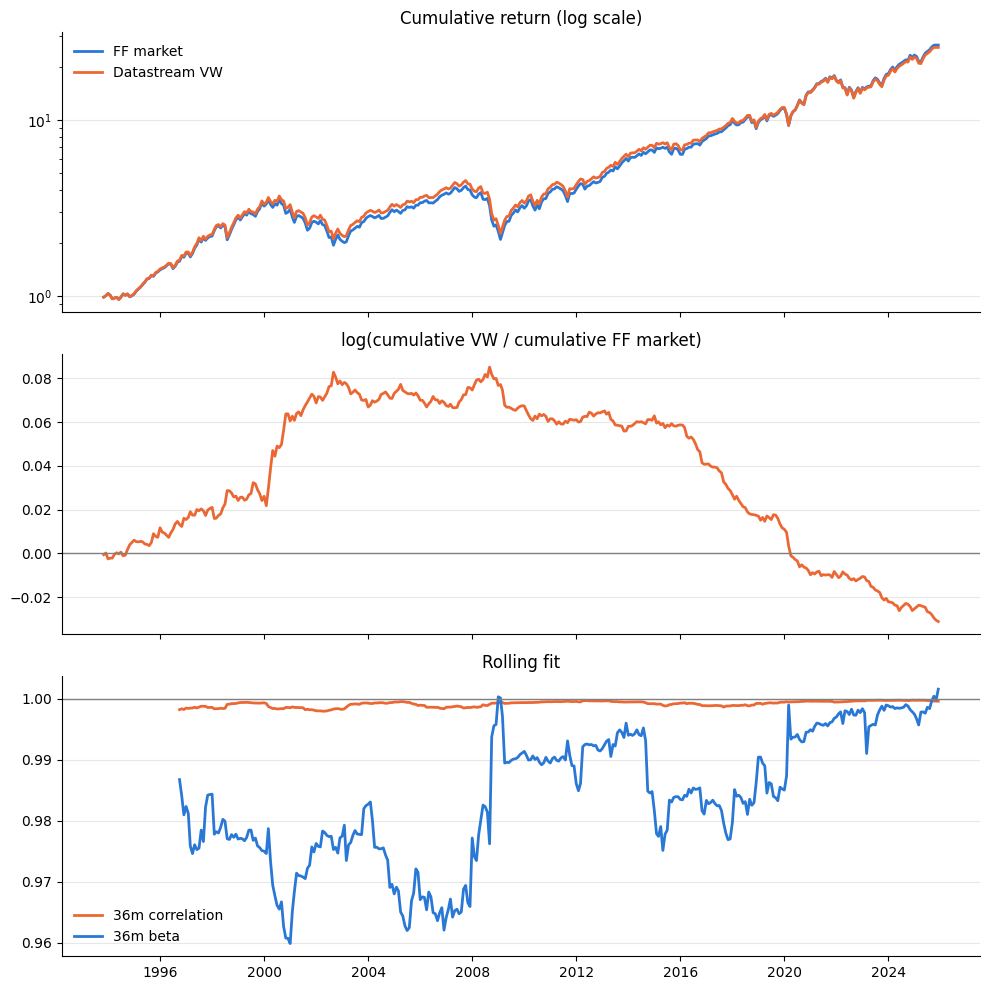

In [7]:
aligned = pd.concat([pf_m["VW"], (ff_m["Mkt-RF"] + ff_m["RF"]).rename("FF_Mkt")], axis=1, join="inner").dropna()
cum = (1 + aligned).cumprod()
roll = ev.rolling_fit(pf_m["VW"], ff_m, ROLLING_MONTHS)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
x = aligned.index.to_timestamp()
axes[0].plot(x, cum["FF_Mkt"], color=C_FF, lw=2, label="FF market")
axes[0].plot(x, cum["VW"], color=C_DS, lw=2, label="Datastream VW")
axes[0].set_yscale("log"); axes[0].set_title("Cumulative return (log scale)"); axes[0].legend(frameon=False)
axes[1].plot(x, np.log(cum["VW"] / cum["FF_Mkt"]), color=C_DS, lw=2)
axes[1].axhline(0, color="grey", lw=1); axes[1].set_title("log(cumulative VW / cumulative FF market)")
axes[2].plot(roll.index.to_timestamp(), roll["corr"], color=C_DS, lw=2, label=f"{ROLLING_MONTHS}m correlation")
axes[2].plot(roll.index.to_timestamp(), roll["beta"], color=C_FF, lw=2, label=f"{ROLLING_MONTHS}m beta")
axes[2].axhline(1, color="grey", lw=1); axes[2].set_title("Rolling fit"); axes[2].legend(frameon=False)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "monthly_vw_vs_ff.png", dpi=150)
plt.show()

In [8]:
sub = ev.subperiod_table(pf_m["VW"], ff_m, SUBPERIODS, periods_per_year=12, hac_lags=6)
sub[["n_obs", "corr", "beta", "r2", "alpha_annual", "alpha_t_hac", "tracking_error_annual"]]

,n_obs,corr,beta,r2,alpha_annual,alpha_t_hac,tracking_error_annual
period,,,,,,,
1993-1999,74,0.9991,0.9768,0.9981,0.0073,3.7481,0.0067
2000-2009,120,0.9988,0.9804,0.9976,0.0035,1.1387,0.0086
2010-2019,120,0.9994,0.9872,0.9987,-0.0042,-2.3251,0.0049
2020-,72,0.9997,0.9988,0.9993,-0.0071,-2.9082,0.0046


**Largest monthly deviations.** Inspect the stocks driving these months (see section 5 for weights).

In [9]:
dev_m = ev.largest_deviations(pf_m["VW"], ff_m, n=10)
dev_m

,Portfolio,FF_Mkt,Diff
2000-04,-0.0505,-0.0593,0.0088
2000-03,0.0651,0.0568,0.0083
2000-05,-0.0311,-0.0389,0.0078
2009-04,0.0943,0.1018,-0.0075
2000-11,-0.0952,-0.1019,0.0067
2000-10,-0.0158,-0.0222,0.0064
2002-09,-0.0965,-0.1020,0.0055
1998-02,0.0687,0.0742,-0.0055
2020-03,-0.1378,-0.1325,-0.0053
2016-11,0.0434,0.0487,-0.0053


## 4. Daily comparison

Event studies use daily data, so the daily VW portfolio should track the FF daily market as well.
Correlation is typically a bit lower than monthly (closing-price timing, holidays). Days with large
deviations are good candidates for a look at the raw data.

In [10]:
pf_d = ev.daily_portfolios(df)
stats_vw_d, res_vw_d = ev.compare_to_market(pf_d["VW"], ff_d, periods_per_year=252, hac_lags=5)
stats_ew_d, _ = ev.compare_to_market(pf_d["EW"], ff_d, periods_per_year=252, hac_lags=5)
daily_stats = pd.DataFrame({"VW": stats_vw_d, "EW": stats_ew_d})
print("Daily correlation check:", ev.flag(stats_vw_d["corr"], T["daily_corr"]))
daily_stats

Daily correlation check: ok


,VW,EW
n_obs,8116,8116
start,1993-10-05 00:00:00,1993-10-05 00:00:00
end,2025-12-31 00:00:00,2025-12-31 00:00:00
corr,0.9995,0.9195
alpha,-0.0000,0.0001
alpha_annual,-0.0006,0.0346
alpha_t_hac,-0.5012,2.6750
beta,0.9920,0.9110
beta_t_hac,"1,383.5482",83.4385
r2,0.9990,0.8455


In [11]:
missing_in_ds = ff_d.index.difference(pf_d.index)
missing_in_ds = missing_in_ds[(missing_in_ds >= pf_d.index.min()) & (missing_in_ds <= pf_d.index.max())]
extra_in_ds = pf_d.index.difference(ff_d.index)
extra_in_ds = extra_in_ds[extra_in_ds <= ff_d.index.max()]
print(f"FF trading days missing in the panel: {len(missing_in_ds)}; panel days that are not FF trading days: {len(extra_in_ds)}")
print("Examples of panel days not in FF (holidays not removed by filter 16?):", list(extra_in_ds[:10].strftime("%Y-%m-%d")))

FF trading days missing in the panel: 0; panel days that are not FF trading days: 1
Examples of panel days not in FF (holidays not removed by filter 16?): ['2001-09-12']


In [12]:
dev_d = ev.largest_deviations(pf_d["VW"], ff_d, n=15)
dev_d

,Portfolio,FF_Mkt,Diff
2009-04-06,-0.0126,-0.0092,-0.0034
2000-04-14,-0.0641,-0.0671,0.0030
1998-02-10,0.0056,0.0083,-0.0027
2000-04-03,-0.0136,-0.0163,0.0027
1996-06-27,0.0037,0.0063,-0.0026
2000-04-04,-0.0095,-0.0119,0.0024
2000-04-18,0.0363,0.0387,-0.0024
1996-06-20,-0.0005,-0.0029,0.0024
2000-07-27,-0.0065,-0.0088,0.0023
2017-09-01,0.0005,0.0028,-0.0023


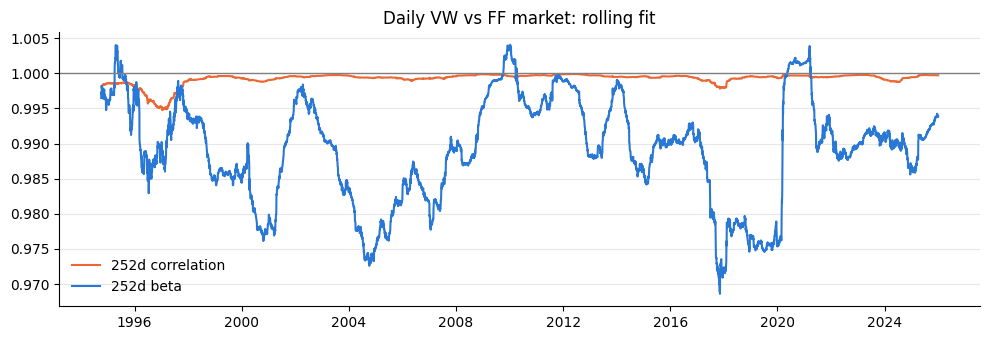

In [13]:
roll_d = ev.rolling_fit(pf_d["VW"], ff_d, ROLLING_DAYS)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(roll_d.index, roll_d["corr"], color=C_DS, lw=1.5, label=f"{ROLLING_DAYS}d correlation")
ax.plot(roll_d.index, roll_d["beta"], color=C_FF, lw=1.5, label=f"{ROLLING_DAYS}d beta")
ax.axhline(1, color="grey", lw=1); ax.legend(frameon=False); ax.set_title("Daily VW vs FF market: rolling fit")
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "daily_rolling_fit.png", dpi=150)
plt.show()

## 5. Universe diagnostics

* **Number of stocks:** should evolve smoothly (U.S. listings peak in the late 1990s and decline
  afterwards). Jumps point to download or filter problems.
* **Max single-stock weight:** in the U.S. market the largest stock rarely exceeds ~7-8%. A higher weight
  usually means a wrong market cap (units, stale MV, duplicate share classes).
* **Implied share changes:** stock-months where market cap growth and return disagree by more than
  a factor of 3 - candidates for MV errors, sorted by size (large stocks matter most for VW).

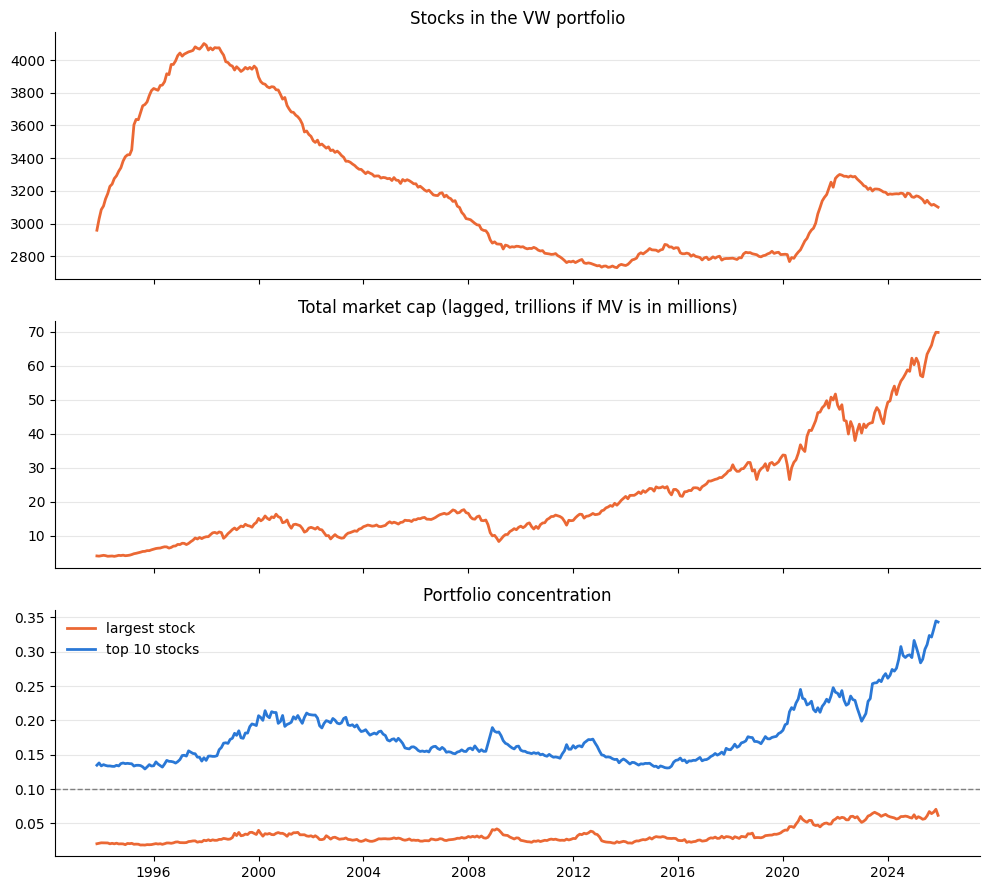

In [14]:
weights = ev.monthly_weights(m)
uni = ev.universe_over_time(m, weights)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
xu = uni.index.to_timestamp()
axes[0].plot(xu, uni["n_stocks"], color=C_DS, lw=2); axes[0].set_title("Stocks in the VW portfolio")
axes[1].plot(xu, uni["total_mcap_lag"] / 1e6, color=C_DS, lw=2); axes[1].set_title("Total market cap (lagged, trillions if MV is in millions)")
axes[2].plot(xu, uni["max_weight"], color=C_DS, lw=2, label="largest stock")
axes[2].plot(xu, uni["top10_weight"], color=C_FF, lw=2, label="top 10 stocks")
axes[2].axhline(T["max_weight"], color="grey", lw=1, ls="--"); axes[2].set_title("Portfolio concentration"); axes[2].legend(frameon=False)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "universe_over_time.png", dpi=150)
plt.show()

In [15]:
print(f"Months with a single-stock weight above {T['max_weight']:.0%}: {(uni['max_weight'] > T['max_weight']).sum()}")
uni.sort_values("max_weight", ascending=False).head(10)

Months with a single-stock weight above 10%: 0


,n_stocks,total_mcap_lag,max_weight,top10_weight,max_weight_stock
Month,,,,,
2025-11,3108,"69,785,183.3017",0.0705,0.3447,694405
2025-08,3124,"64,629,542.6136",0.0672,0.3236,694405
2025-10,3117,"68,322,676.9559",0.0664,0.3325,694405
2023-07,3211,"46,136,181.9875",0.0661,0.2545,992816
2023-06,3199,"43,252,100.0140",0.0645,0.2533,992816
2023-08,3211,"47,669,219.5240",0.0644,0.2548,992816
2025-09,3112,"65,970,952.5242",0.0642,0.3213,694405
2023-12,3191,"46,815,526.8543",0.0631,0.2680,992816
2023-09,3209,"46,711,364.0773",0.0629,0.2589,992816


In [16]:
mv_flags = ev.mcap_consistency(m, threshold=3.0)
print(f"{len(mv_flags):,} stock-months with implied share change > 3x or < 1/3x")
mv_flags.head(20)

906 stock-months with implied share change > 3x or < 1/3x


,Stock,Month,LagMCAP,MarketCAP,MonthlyReturn,ImpliedShareChange
1137253,904853,2008-03,"154,201.1000","46,804.2500",-0.0053,0.3051
965893,873886,2019-09,"36,100.8400","10,120.0700",0.0203,0.2747
621473,54060C,2000-01,"30,964.8300","1,511.9090",-0.1483,0.0573
335658,321354,2020-07,"25,605.4100","10,484.4400",0.2505,0.3274
129842,2599VY,2023-07,"23,856.1400",33.5138,0.1789,0.0012
774456,687566,2007-10,"22,089.3000","1,221.6390",-0.1736,0.0669
293864,30763D,2005-11,"20,320.6800","1,829.2050",-0.0092,0.0908
1434961,946119,2000-07,"20,216.7500","4,758.1680",0.0619,0.2216
774449,687566,2007-03,"16,623.0700","1,272.2460",0.1509,0.0665
509002,50644F,2021-10,"16,584.5200","63,662.7700",0.0202,3.7628


## 6. Return profile

Landis & Skouras (2021) report about 30% zero daily returns in their filtered U.S. sample (23% in CRSP)
and per-stock daily volatilities between 0.11% and 40%. Much higher zero shares suggest stale data or
low-precision downloads.

In [17]:
profile = ev.daily_return_profile(df)
profile

,stockdays,share_zero_returns,share_abs_ret_gt_50pct,share_missing_returns,IsFilled_mean,DelistingReturnApplied_sum
Year,,,,,,
1993,188444,0.1866,0.0000,0.0001,0.0380,0.0000
1994,812184,0.1879,0.0000,0.0000,0.0489,2.0000
1995,912631,0.1898,0.0000,0.0000,0.0464,6.0000
1996,989401,0.1807,0.0000,0.0001,0.0488,3.0000
1997,1027072,0.1481,0.0001,0.0003,0.0504,6.0000
1998,1026265,0.1145,0.0001,0.0003,0.0533,2.0000
1999,999095,0.1159,0.0002,0.0004,0.0521,2.0000
2000,972809,0.1051,0.0003,0.0003,0.0561,10.0000
2001,924104,0.1348,0.0001,0.0001,0.0844,34.0000


In [18]:
ev.stock_volatility_profile(df)

count   12,322.0000
mean         0.0398
std          0.0507
min          0.0000
1%           0.0058
5%           0.0145
50%          0.0320
95%          0.0822
99%          0.1691
max          2.7136
Name: Return, dtype: float64

## 7. Impact of the delisting return

Compares portfolios with and without the delisting adjustment (-35% on the last observation of each
delisted stock). The EW portfolio should react more than VW, because delisted stocks are mostly small.

In [19]:
df_nodl = ev.undo_delisting_adjustment(df, DELISTING_RETURN)
pf_m_nodl = ev.monthly_portfolios(ev.monthly_panel(df_nodl))
delisting_impact = pd.DataFrame({
    "with delisting return": pf_m.mean() * 12,
    "without delisting return": pf_m_nodl.mean() * 12,
})
delisting_impact["difference p.a."] = delisting_impact.iloc[:, 0] - delisting_impact.iloc[:, 1]
stats_vw_nodl, _ = ev.compare_to_market(pf_m_nodl["VW"], ff_m, 12, 6)
print(f"VW vs FF market without delisting return: corr {stats_vw_nodl['corr']:.4f}, beta {stats_vw_nodl['beta']:.4f}, "
      f"alpha p.a. {stats_vw_nodl['alpha_annual']:.4f}")
delisting_impact

VW vs FF market without delisting return: corr 0.9992, beta 0.9856, alpha p.a. 0.0039


,with delisting return,without delisting return,difference p.a.
VW,0.1133,0.1171,-0.0038
EW,0.1228,0.1328,-0.0100


## 8. Save results

In [20]:
checks.to_csv(OUTPUT_DIR / "checks_summary.csv")
monthly_stats.to_csv(OUTPUT_DIR / "monthly_stats.csv")
daily_stats.to_csv(OUTPUT_DIR / "daily_stats.csv")
ff3_table.to_csv(OUTPUT_DIR / "ff3_regressions.csv")
sub.to_csv(OUTPUT_DIR / "subperiods_vw.csv")
dev_m.to_csv(OUTPUT_DIR / "largest_deviations_monthly.csv")
dev_d.to_csv(OUTPUT_DIR / "largest_deviations_daily.csv")
uni.to_csv(OUTPUT_DIR / "universe_over_time.csv")
mv_flags.to_csv(OUTPUT_DIR / "mcap_consistency_flags.csv", index=False)
profile.to_csv(OUTPUT_DIR / "daily_return_profile.csv")
delisting_impact.to_csv(OUTPUT_DIR / "delisting_impact.csv")
pf_m.to_csv(OUTPUT_DIR / "portfolios_monthly.csv")
pf_d.to_csv(OUTPUT_DIR / "portfolios_daily.csv")
print(f"Saved to {OUTPUT_DIR}")

Saved to D:\Datastream\PriceData\US\processed\sanity_checks_0.25
